In [9]:
from pathlib import Path

import ase.io
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

def ethene_descriptors(atoms_list):
    """Return C=C bond lengths (Å) and folded H-C-C-H dihedrals (degrees)."""
    bond_lengths = np.asarray([atoms.get_distance(0, 1) for atoms in atoms_list])
    dihedrals = np.asarray([atoms.get_dihedral(2, 0, 1, 3) for atoms in atoms_list])
    return bond_lengths, np.minimum(dihedrals, 360.0 - dihedrals)

def surface_grid(bond_lengths, dihedrals, energy):
    """Place a gridded energy surface on its bond-length/dihedral grid."""
    bond_values = np.round(bond_lengths, 8)
    dihedral_values = np.round(dihedrals, 8)
    bond_grid = np.unique(bond_values)
    dihedral_grid = np.unique(dihedral_values)
    grid = np.full((len(dihedral_grid), len(bond_grid)), np.nan)
    grid[np.searchsorted(dihedral_grid, dihedral_values), np.searchsorted(bond_grid, bond_values)] = energy
    return bond_grid, dihedral_grid, grid


In [10]:
DATA_DIR = Path("../data/A01_ethene/static")
CASSCF_XYZ = DATA_DIR / "A01_ethene_grid_static_CASSCF_FINAL.xyz"
NEVPT2_XYZ = DATA_DIR / "A01_ethene_grid_static_NEVPT2_FINAL.xyz"
QSE_NPY = DATA_DIR / "qse_sv_2e2o_ccpvdz-2.npy"

casscf_atoms = ase.io.read(CASSCF_XYZ, index=":")
nevpt2_atoms = ase.io.read(NEVPT2_XYZ, index=":")
HARTREE_TO_EV = 27.211386245988
qse_energies = np.load(QSE_NPY) * HARTREE_TO_EV
casscf_energies = np.asarray([atoms.info["REF_energy"] for atoms in casscf_atoms]).squeeze(axis=1)
nevpt2_energies = np.asarray([atoms.info["REF_energy"] for atoms in nevpt2_atoms]).squeeze(axis=1)

if qse_energies.shape != (len(casscf_atoms), 3):
    raise ValueError(f"Expected QSE shape {(len(casscf_atoms), 3)}, got {qse_energies.shape}.")
if casscf_energies.shape != nevpt2_energies.shape:
    raise ValueError("CASSCF and NEVPT2 energy arrays do not have the same shape.")

# Every array is shifted by its global (all-state) minimum, not a per-state minimum.
datasets = {
    "QSE": (casscf_atoms, qse_energies - qse_energies.min(), "eV"),
    "CASSCF": (casscf_atoms, casscf_energies - casscf_energies.min(), "eV"),
    "NEVPT2": (nevpt2_atoms, nevpt2_energies - nevpt2_energies.min(), "eV"),
}

# Differences use the original energies (after QSE's Hartree-to-eV conversion),
# so they retain the absolute offset between electronic-structure methods.
absolute_differences = {
    "|CASSCF − NEVPT2|": np.abs(casscf_energies - nevpt2_energies),
    "|QSE − NEVPT2|": np.abs(qse_energies - nevpt2_energies),
}

for name, (atoms_list, energies, unit) in datasets.items():
    print(f"{name}: {len(atoms_list)} geometries, {energies.shape[1]} states, minimum shifted to {energies.min():.1f} {unit}")


QSE: 3731 geometries, 3 states, minimum shifted to 0.0 eV
CASSCF: 3731 geometries, 3 states, minimum shifted to 0.0 eV
NEVPT2: 3731 geometries, 3 states, minimum shifted to 0.0 eV


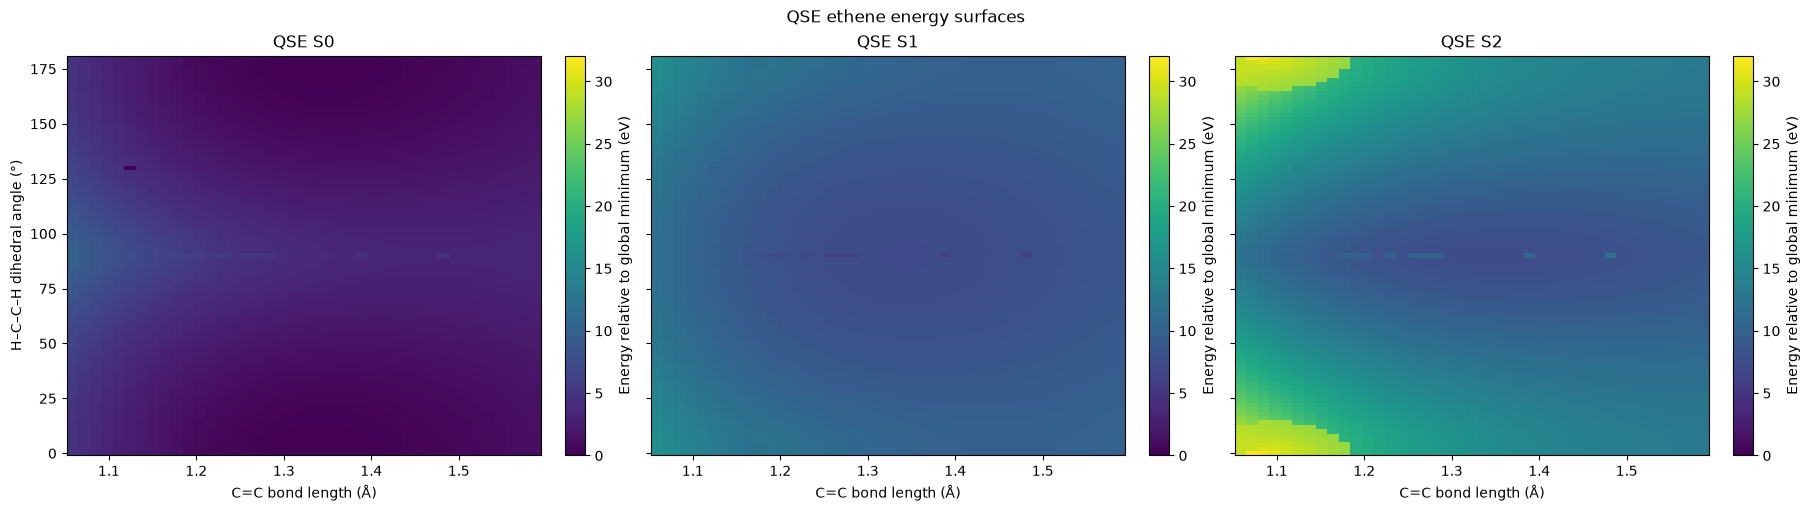

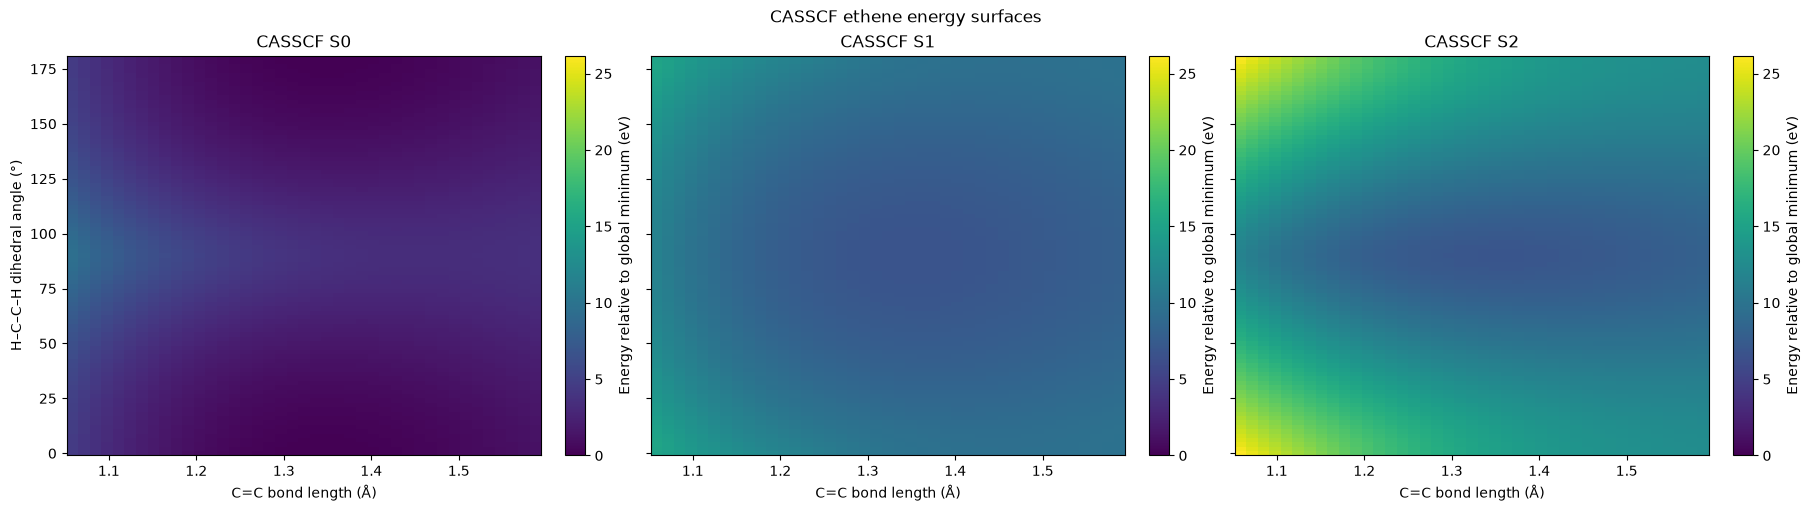

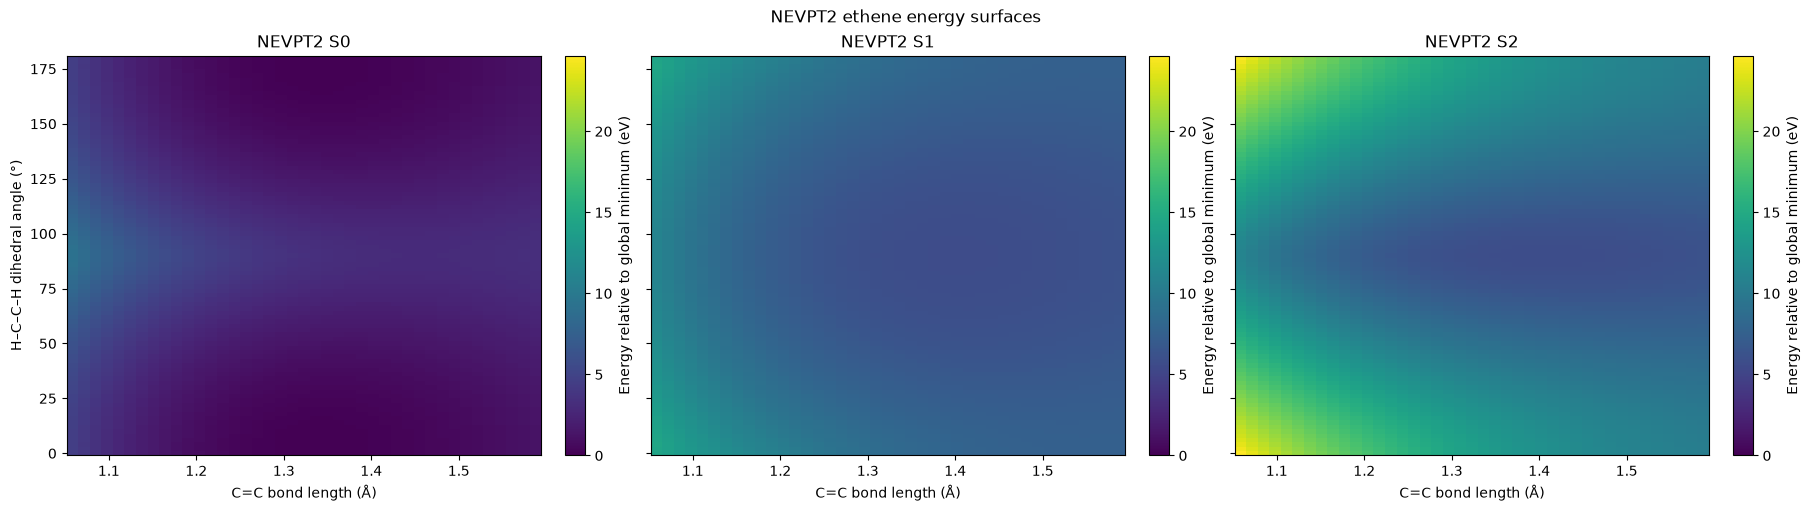

In [11]:
for dataset_name, (atoms_list, relative_energies, unit) in datasets.items():
    bond_lengths, dihedrals = ethene_descriptors(atoms_list)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)
    vmax = relative_energies.max()  # shared scale across S0, S1, and S2 for this dataset

    for state, ax in enumerate(axes):
        bond_grid, dihedral_grid, energy_grid = surface_grid(
            bond_lengths, dihedrals, relative_energies[:, state]
        )
        image = ax.pcolormesh(
            bond_grid, dihedral_grid, energy_grid, shading="nearest", cmap="viridis", vmin=0, vmax=vmax
        )
        fig.colorbar(image, ax=ax, label=f"Energy relative to global minimum ({unit})")
        ax.set_title(f"{dataset_name} S{state}")
        ax.set_xlabel("C=C bond length (Å)")

    axes[0].set_ylabel("H–C–C–H dihedral angle (°)")
    fig.suptitle(f"{dataset_name} ethene energy surfaces")
    plt.show()


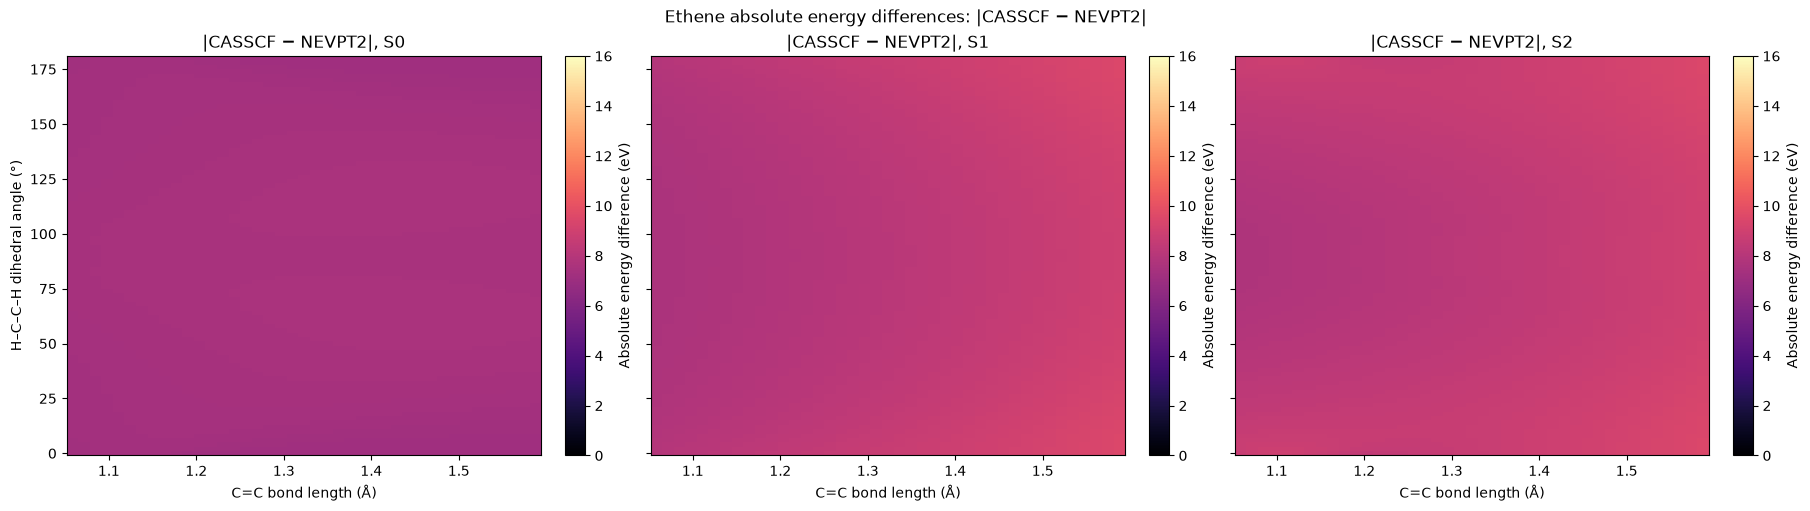

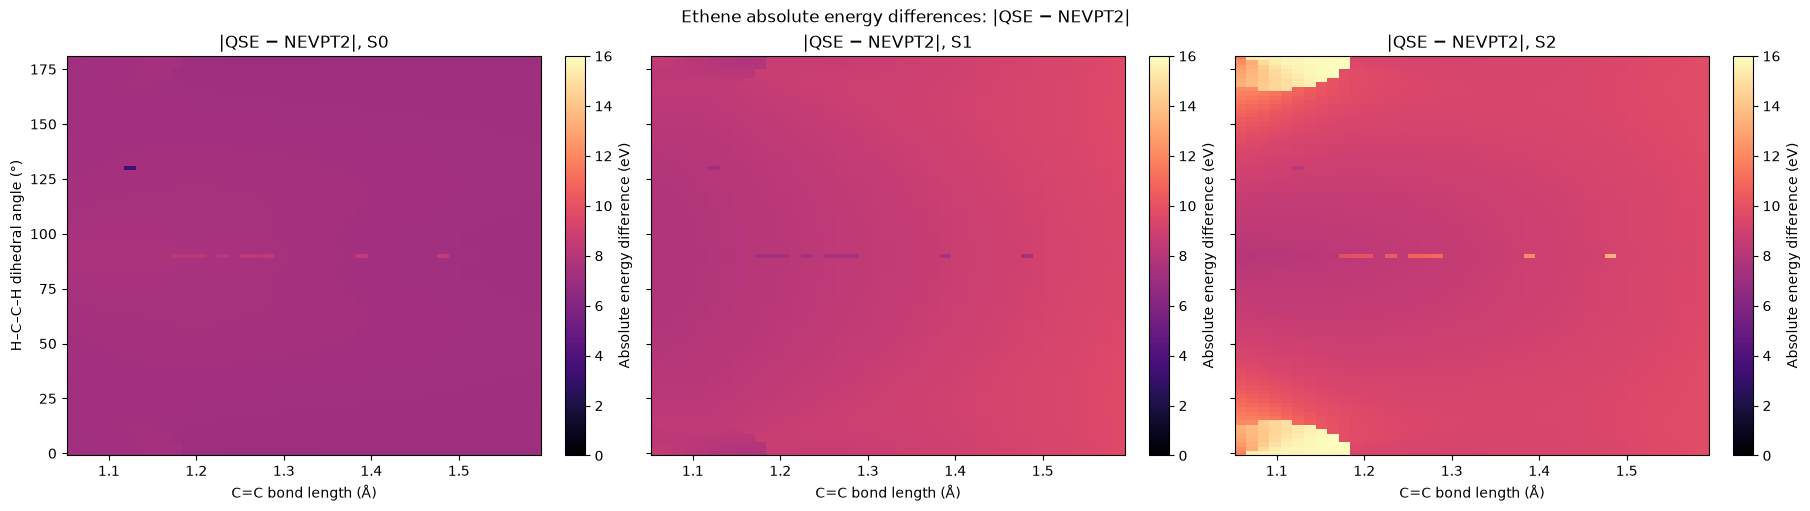

In [13]:
bond_lengths, dihedrals = ethene_descriptors(casscf_atoms)

for comparison_name, absolute_error in absolute_differences.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)
    vmax = absolute_error.max()  # shared scale across S0, S1, and S2

    for state, ax in enumerate(axes):
        bond_grid, dihedral_grid, difference_grid = surface_grid(
            bond_lengths, dihedrals, absolute_error[:, state]
        )
        image = ax.pcolormesh(
            bond_grid, dihedral_grid, difference_grid, shading="nearest", cmap="magma", vmin=0, vmax=16
        )
        fig.colorbar(image, ax=ax, label="Absolute energy difference (eV)")
        ax.set_title(f"{comparison_name}, S{state}")
        ax.set_xlabel("C=C bond length (Å)")

    axes[0].set_ylabel("H–C–C–H dihedral angle (°)")
    fig.suptitle(f"Ethene absolute energy differences: {comparison_name}")
    plt.show()
